<a href="https://colab.research.google.com/github/monish-1394/116/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***dependency***

In [ ]:
!pip install numpy pandas

# ***`loading`***

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/coffee dataset/synthetic_coffee_health_10000.csv")
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

,0
ID,0
Age,0
Gender,0
Country,0
Coffee_Intake,0
Caffeine_mg,0
Sleep_Hours,0
Sleep_Quality,0
BMI,0
Heart_Rate,0


# ***`preprocessing`***

In [ ]:
df = df.drop(['ID', 'Coffee_Intake'], axis=1)
print(df.columns)

Index(['Age', 'Gender', 'Country', 'Caffeine_mg', 'Sleep_Hours',
       'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level',
       'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking',
       'Alcohol_Consumption'],
      dtype='object')


In [ ]:
#count categories in countries
df['Country'].value_counts()

,count
Country,
Canada,543
India,524
Norway,523
China,521
UK,519
Sweden,513
South Korea,512
Finland,510
Italy,509


In [ ]:
#droping country
df = df.drop('Country', axis=1)

In [ ]:
#count in gender
df['Gender'].value_counts()

,count
Gender,
Female,5001
Male,4773
Other,226


In [ ]:
#mapping
df['Gender'] = df['Gender'].map({'Female': 0,'Other':1, 'Male': 2})

In [ ]:
#count in sleep-quality
df['Sleep_Quality'].value_counts()

,count
Sleep_Quality,
Good,5637
Fair,2050
Excellent,1352
Poor,961


In [ ]:
#mapping
df['Sleep_Quality'] = df['Sleep_Quality'].map({
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
})


In [ ]:
#count in sleep-quality
df['Stress_Level'].value_counts()

,count
Stress_Level,
Low,6989
Medium,2050
High,961


In [ ]:
#mapping
df['Stress_Level'] = df['Stress_Level'].map({'Low': 0,'Medium':1, 'High': 2})

In [ ]:
#count in Health_Issues
df['Health_Issues'].value_counts()

,count
Health_Issues,
Mild,3579
Moderate,463
Severe,17


In [ ]:
#mapping
df['Health_Issues'] = df['Health_Issues'].map({
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}).fillna(0)

In [ ]:
#count in Occupation
df['Occupation'].value_counts()

,count
Occupation,
Office,2073
Other,2038
Student,1968
Healthcare,1964
Service,1957


In [ ]:
#one-hot encoding for occupation
df = pd.get_dummies(df, columns=['Occupation'])

In [ ]:
#checking dataset
df.head()


,Age,Gender,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Smoking,Alcohol_Consumption,Occupation_Healthcare,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student
0,40,2,328.1,7.5,2,24.9,78,0,14.5,0.0,0,0,False,False,True,False,False
1,33,2,94.1,6.2,2,20.0,67,0,11.0,0.0,0,0,False,False,False,True,False
2,42,2,503.7,5.9,1,22.7,59,1,11.2,1.0,0,0,False,True,False,False,False
3,53,2,249.2,7.3,2,24.7,71,0,6.6,1.0,0,0,False,False,True,False,False
4,32,0,298.0,5.3,1,24.1,76,1,8.5,1.0,0,1,False,False,False,False,True


## ***`model building`***

In [ ]:
#col check
print(df.columns)

Index(['Age', 'Gender', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI',
       'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours',
       'Health_Issues', 'Smoking', 'Alcohol_Consumption',
       'Occupation_Healthcare', 'Occupation_Office', 'Occupation_Other',
       'Occupation_Service', 'Occupation_Student'],
      dtype='object')


In [ ]:
from google.colab import files
df.to_csv("datacy.csv", index=False)
files.download("datacy.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sleep-quality model

In [ ]:
#copy the df
df_copy = df.copy()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X = df_copy.drop('Sleep_Quality', axis=1)
y = df_copy['Sleep_Quality']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
'''
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
'''

# Model
'''
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
model.fit(X_train, y_train)'''

model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', multi_class='multinomial',
                   random_state=42)

In [ ]:
# Evaluate
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       190
           1       0.78      0.89      0.83       375
           2       0.92      0.73      0.82      1162
           3       0.49      0.82      0.61       273

    accuracy                           0.79      2000
   macro avg       0.78      0.84      0.80      2000
weighted avg       0.84      0.79      0.80      2000


Confusion Matrix:
 [[175  15   0   0]
 [ 15 335  23   2]
 [  0  78 849 235]
 [  0   0  48 225]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=None
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9905

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00       375
           2       0.99      0.99      0.99      1162
           3       0.97      0.96      0.97       273

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
 [[ 190    0    0    0]
 [   0  375    0    0]
 [   0    0 1153    9]
 [   0    0   10  263]]


model archieve

In [ ]:
import joblib
from google.colab import files

# Save model as .pkl file
joblib.dump(rf, "sleep_quality_model.pkl")

# Download the file
files.download("sleep_quality_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

stress-level model

In [ ]:
df_rf = df.copy()

# Define input (X) and output (y)
X = df_rf.drop('Stress_Level', axis=1)
y = df_rf['Stress_Level']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_stress = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=None
)

rf_stress.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
y_pred = rf_stress.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1435
           1       1.00      1.00      1.00       375
           2       1.00      1.00      1.00       190

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:
 [[1435    0    0]
 [   0  375    0]
 [   0    0  190]]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")


Mean Squared Error: 0.059
Root Mean Squared Error: 0.244
R² Score: 0.860


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import numpy as np
y_pred_class = np.round(y_pred).clip(0, 3).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_class))


Accuracy: 0.997

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1435
           1       0.98      1.00      0.99       375
           2       1.00      0.99      1.00       190

    accuracy                           1.00      2000
   macro avg       0.99      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:
 [[1430    5    0]
 [   0  375    0]
 [   0    1  189]]


In [ ]:
import joblib
from google.colab import files
joblib.dump(rf_stress, "stress_level_model.pkl")

files.download("stress_level_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

heart-rate pred model

In [ ]:
# Calculate variance of the 'Heart_Rate' column
variance = df['Heart_Rate'].var()

print(f"Variance of Heart Rate: {variance:.2f}")


Variance of Heart Rate: 96.49


In [ ]:
range_val = df['Heart_Rate'].max() - df['Heart_Rate'].min()
print(f"Range of Heart Rate: {range_val:.2f}")


Range of Heart Rate: 59.00


In [ ]:
df_hrt = df.copy()

In [ ]:
#removing correlated cols
df_hrt = df_hrt.drop(['Sleep_Quality', 'Stress_Level'], axis=1)

In [ ]:
df_hrt.head()

,Age,Gender,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Health_Issues,Smoking,Alcohol_Consumption,Occupation_Healthcare,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student
0,40,2,328.1,7.5,24.9,78,14.5,0.0,0,0,False,False,True,False,False
1,33,2,94.1,6.2,20.0,67,11.0,0.0,0,0,False,False,False,True,False
2,42,2,503.7,5.9,22.7,59,11.2,1.0,0,0,False,True,False,False,False
3,53,2,249.2,7.3,24.7,71,6.6,1.0,0,0,False,False,True,False,False
4,32,0,298.0,5.3,24.1,76,8.5,1.0,0,1,False,False,False,False,True


🔹 Correlation of Each Feature with Heart Rate:

Heart_Rate                 1.000000
Caffeine_mg                0.060027
Health_Issues              0.025014
Occupation_Other           0.011548
Occupation_Service         0.006568
Smoking                    0.006534
Age                       -0.000197
Occupation_Student        -0.002147
Physical_Activity_Hours   -0.002919
Occupation_Office         -0.004061
Gender                    -0.006068
BMI                       -0.009362
Alcohol_Consumption       -0.009474
Occupation_Healthcare     -0.011977
Sleep_Hours               -0.036219
Name: Heart_Rate, dtype: float64


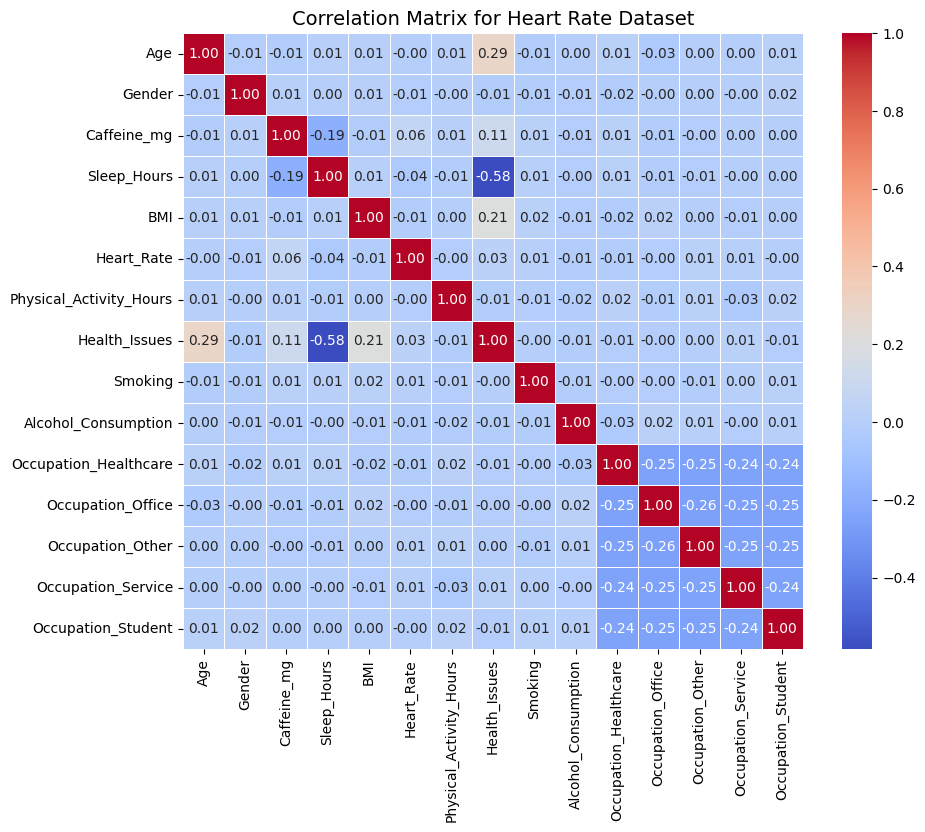

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
corr_matrix = df_hrt.corr(numeric_only=True)

# Display correlation with Heart_Rate specifically
print("🔹 Correlation of Each Feature with Heart Rate:\n")
print(corr_matrix['Heart_Rate'].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Heart Rate Dataset", fontsize=14)
plt.show()


In [ ]:
import pandas as pd
import numpy as np

#loading dataset
df_lf = pd.read_csv("/content/drive/MyDrive/coffee dataset/synthetic_coffee_health_10000.csv")

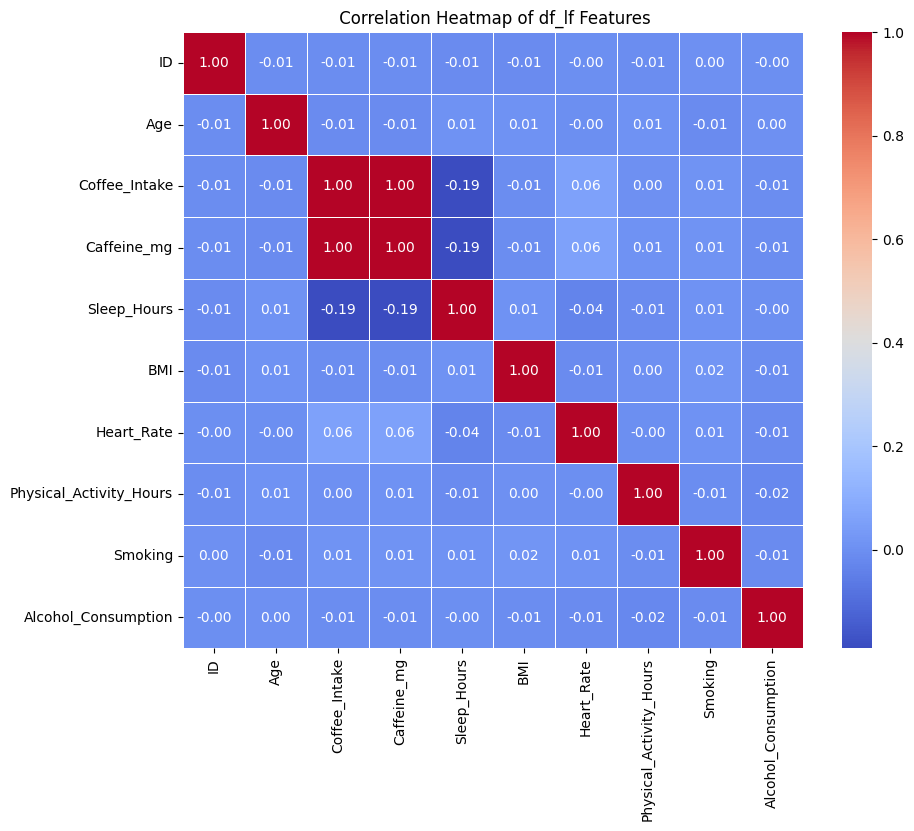

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = df_lf.corr(numeric_only=True)

# Display correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title(" Correlation Heatmap of df_lf Features")
plt.show()


 Correlation Table:

                     Gender  Caffeine_mg  Sleep_Hours  Sleep_Quality   BMI  \
Gender                 1.00         0.01         0.00          -0.00  0.01   
Caffeine_mg            0.01         1.00        -0.19          -0.17 -0.01   
Sleep_Hours            0.00        -0.19         1.00           0.91  0.01   
Sleep_Quality         -0.00        -0.17         0.91           1.00  0.01   
BMI                    0.01        -0.01         0.01           0.01  1.00   
Heart_Rate            -0.01         0.06        -0.04          -0.04 -0.01   
Stress_Level           0.00         0.15        -0.79          -0.91  0.00   
Health_Issues         -0.01         0.11        -0.58          -0.66  0.21   
Smoking               -0.01         0.01         0.01           0.01  0.02   
Alcohol_Consumption   -0.01        -0.01        -0.00          -0.00 -0.01   

                     Heart_Rate  Stress_Level  Health_Issues  Smoking  \
Gender                    -0.01          0.00  

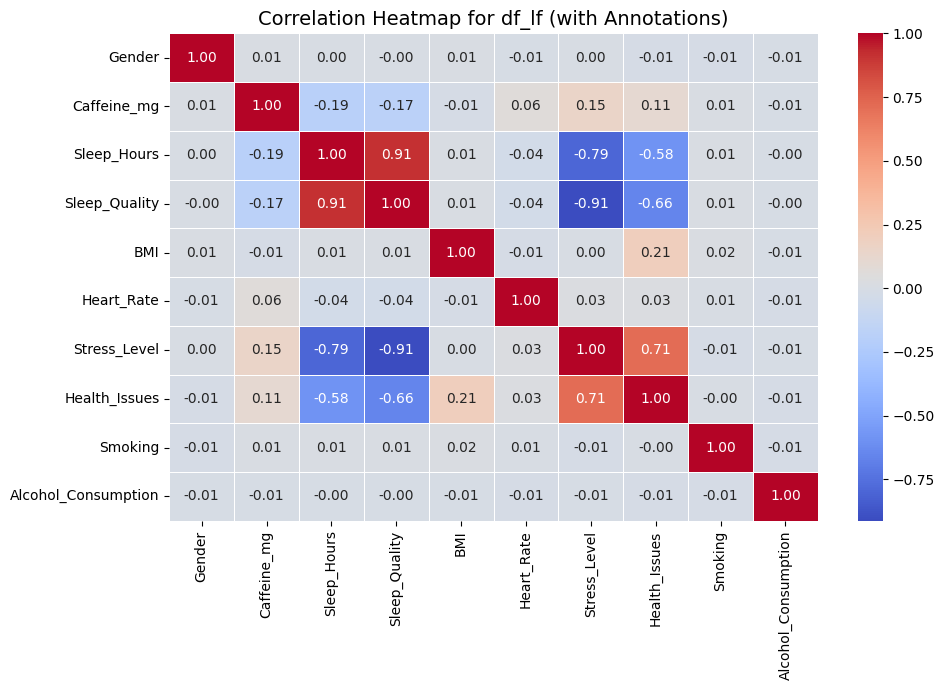


 Correlation of Each Feature with Heart_Rate:

Heart_Rate             1.000
Caffeine_mg            0.060
Stress_Level           0.027
Health_Issues          0.025
Smoking                0.007
Gender                -0.006
BMI                   -0.009
Alcohol_Consumption   -0.009
Sleep_Quality         -0.036
Sleep_Hours           -0.036
Name: Heart_Rate, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df_lf = pd.read_csv("/content/drive/MyDrive/coffee dataset/synthetic_coffee_health_10000.csv")

#Drop irrelevant columns
df_lf = df_lf.drop(['ID', 'Coffee_Intake', 'Country', 'Occupation',
                    'Physical_Activity_Hours', 'Age'], axis=1)

#Mapping categorical values
df_lf['Gender'] = df_lf['Gender'].map({'Female': 0, 'Other': 1, 'Male': 2})
df_lf['Stress_Level'] = df_lf['Stress_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_lf['Health_Issues'] = df_lf['Health_Issues'].map({
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}).fillna(0)
df_lf['Sleep_Quality'] = df_lf['Sleep_Quality'].map({
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
})

#Standardize all columns EXCEPT Heart_Rate
exclude_cols = ['Heart_Rate']
cols_to_scale = [col for col in df_lf.columns if col not in exclude_cols]

scaler = StandardScaler()
df_lf[cols_to_scale] = scaler.fit_transform(df_lf[cols_to_scale])

#Correlation Table
corr = df_lf.corr(numeric_only=True)

# Display correlation table
print(" Correlation Table:\n")
print(corr.round(2))

#Visualize Correlation Heatmap (with annotations)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title("Correlation Heatmap for df_lf (with Annotations)", fontsize=14)
plt.tight_layout()
plt.show()

#Show correlation with Heart_Rate
corr_with_hr = corr['Heart_Rate'].sort_values(ascending=False)
print("\n Correlation of Each Feature with Heart_Rate:\n")
print(corr_with_hr.round(3))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#Define features (X) and target (y)
X = df_lf.drop('Heart_Rate', axis=1)
y = df_lf['Heart_Rate']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#Make predictions
y_pred = lr_model.predict(X_test)

#Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100

#Print results
print("\n Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f" Model Accuracy: {accuracy:.2f}%")

#Show feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n Feature Importance (Linear Coefficients):\n")
print(feature_importance)



 Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 7.98
Root Mean Squared Error (RMSE): 9.88
R² Score: 0.0036
 Model Accuracy: 0.36%

 Feature Importance (Linear Coefficients):

               Feature  Coefficient
6              Smoking     0.195276
5        Health_Issues     0.173363
1          Caffeine_mg     0.003892
3                  BMI    -0.026446
0               Gender    -0.110341
7  Alcohol_Consumption    -0.238597
2          Sleep_Hours    -0.256720
4         Stress_Level    -0.286105


proper dependencies



In [ ]:
!python --version

Python 3.12.12


In [ ]:
import sklearn, numpy, pandas, joblib
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)


scikit-learn: 1.6.1
numpy: 2.0.2
pandas: 2.2.2
joblib: 1.5.2
